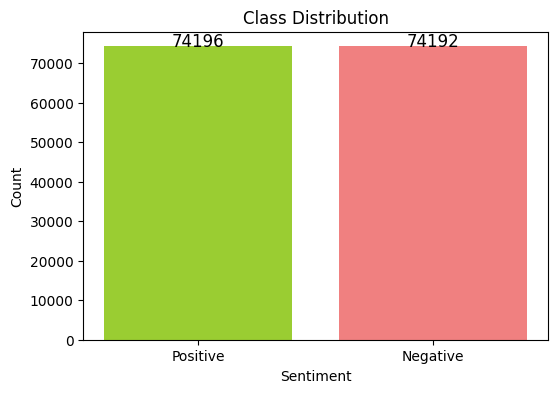

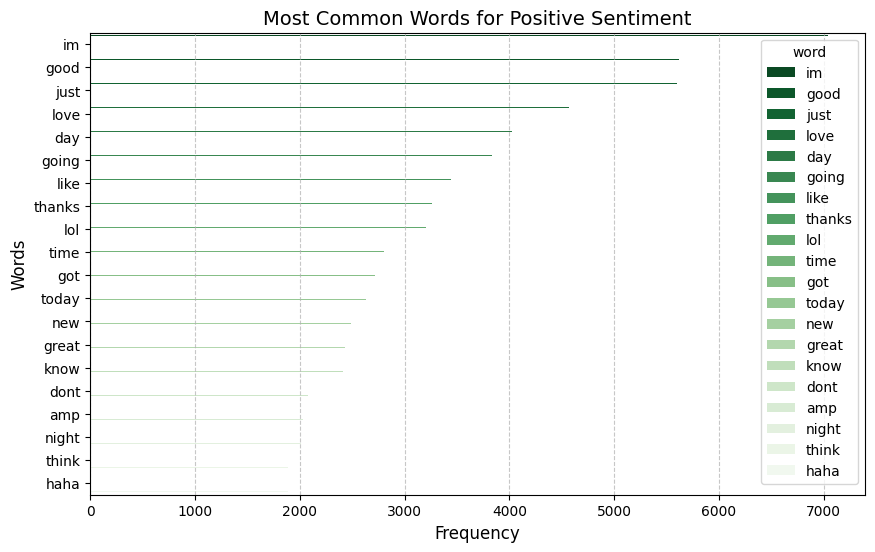

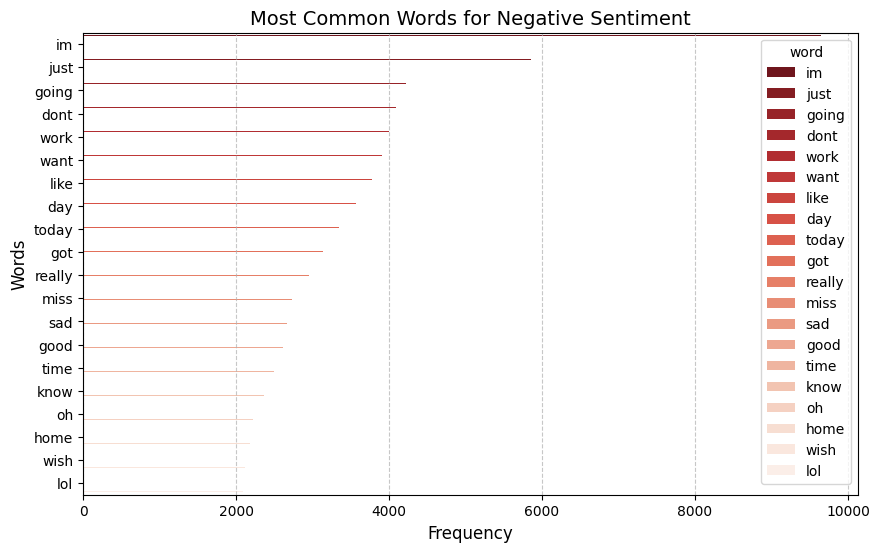

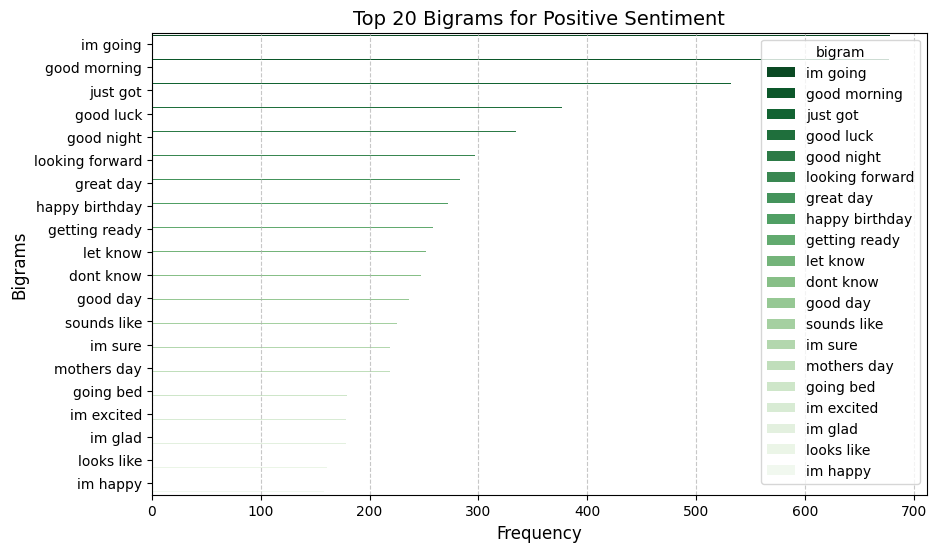

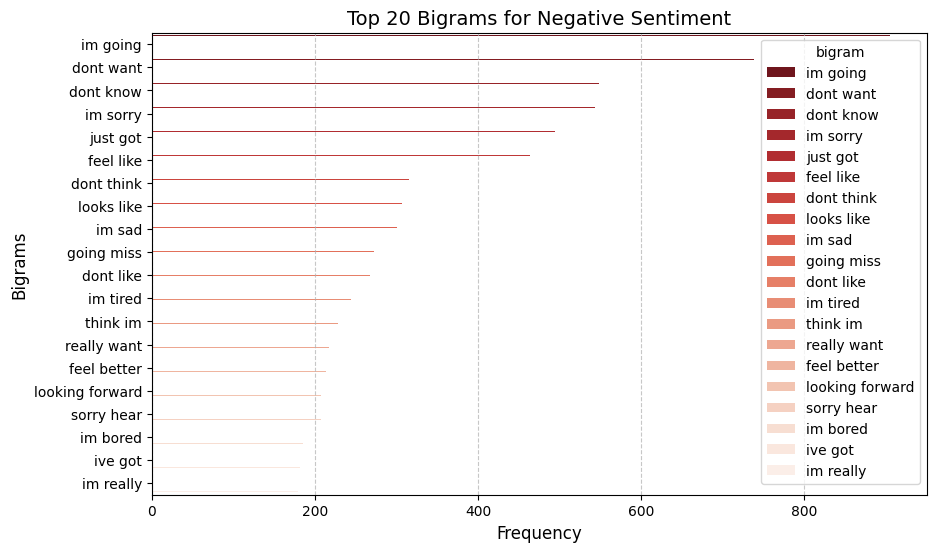

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


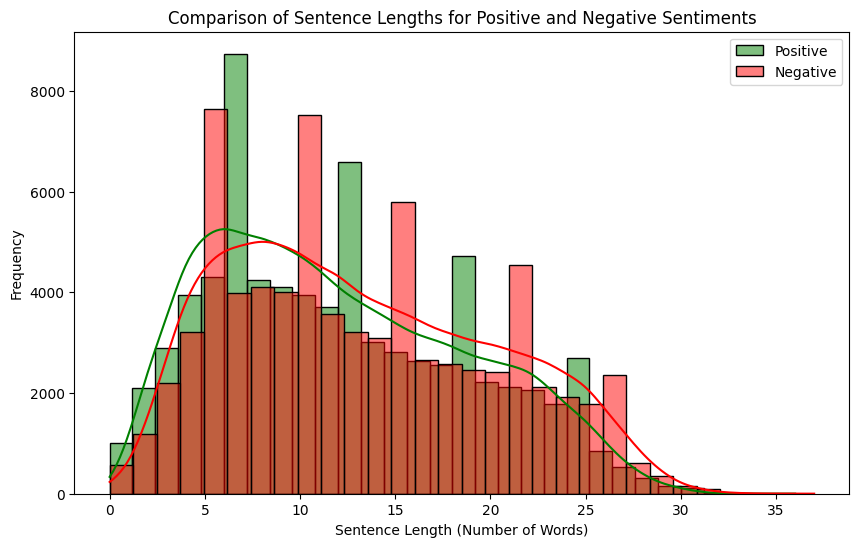

Accuracy: 0.80300
Precision: 0.79914
Recall: 0.80947
F1 Score: 0.80427
              precision    recall  f1-score   support

           0       0.81      0.80      0.80     21197
           1       0.80      0.81      0.80     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



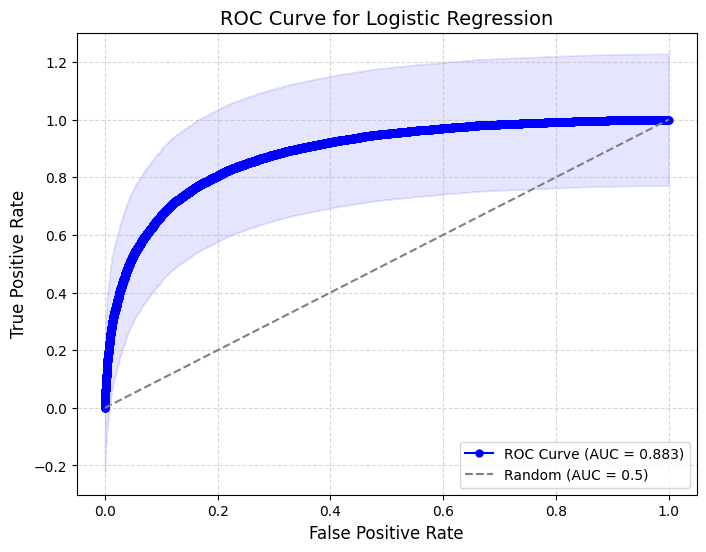

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

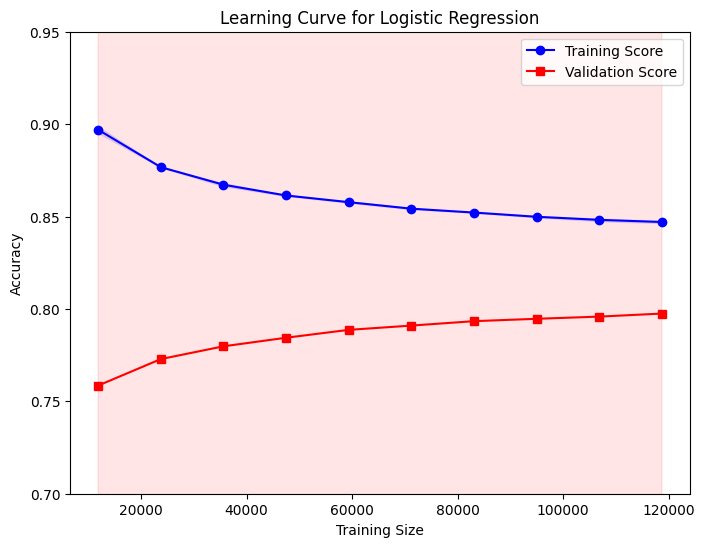

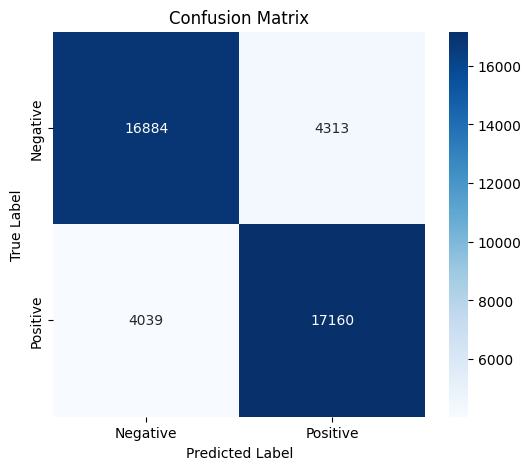

In [1]:
# Import basic libraries
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import learning_curve
from matplotlib import pyplot as plt
import emoji
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# Load datasets
train_dataset = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv")
validation_dataset = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv")
test_dataset = pd.read_csv("/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv")

# Define text preprocessing function
def preprocess_text(text):
    if isinstance(text, str):  # Ensure input is a string
        
        text = text.lower() #Convert to lowercase

        #Remove URLs
        text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

        #Remove hashtags and @s
        text = re.sub(r"@\w+|#\w+", "", text)

        #Remove punctuation
        text = re.sub(r"[^a-zA-Z0-9\s?!]", "", text)\

        #Correct the spelling mistakes
        text = re.sub(r"\b(luv)\b", "love", text)
        text = re.sub(r"\b(amzing)\b", "amazing", text)
        text = re.sub(r"\b(terible)\b", "terrible", text)
        text = re.sub(r"\b(excelent)\b", "excellent", text)
        text = re.sub(r"\b(perfonmence)\b", "performance", text)
        text = re.sub(r"\b(gud)\b", "good", text)
        text = re.sub(r"\b(vry)\b", "very", text)
        text = re.sub(r"\b(fntstic)\b", "fantastic", text)
        text = re.sub(r"\b(gr8)\b", "great", text)
        text = re.sub(r"\b(horrble)\b", "horrible", text)
        text = re.sub(r"\b(wanna)\b", "want to", text)
        text = re.sub(r"\b(gonna)\b", "going to", text)
        text = re.sub(r"\b(str8)\b", "straight", text)
        text = re.sub(r"\b(2night)\b", "tonight", text)
        text = re.sub(r"\b(thru)\b", "through", text)


        
        #If more than 3 characters --> Convert to 3 characters (e.g. heyyyyy --> heyyy)
        text = re.sub(r"(.)\1{2,}", r"\1", text)

        #Remove specific words (they are the most common words found in EDA for both positive and negative instances)
        
        #words = text.split()
        #text = " ".join([word for word in words if word not in stopwords_to_remove])
    
    return text

# Apply preprocessing to dataset text columns
train_dataset["Text"] = train_dataset["Text"].apply(preprocess_text)
validation_dataset["Text"] = validation_dataset["Text"].apply(preprocess_text)
test_dataset["Text"] = test_dataset["Text"].apply(preprocess_text)



#Split datasets into positives and negatives
positive_dataset = train_dataset[train_dataset["Label"] == 1].copy()
negative_dataset = train_dataset[train_dataset["Label"] == 0].copy()


#Get ngrams function used for later
def get_ngrams(text_data, ngram_range=(1, 1)):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    ngram_matrix = vectorizer.fit_transform(text_data)
    ngram_freq = dict(zip(vectorizer.get_feature_names_out(), np.asarray(ngram_matrix.sum(axis=0)).ravel()))
    return sorted(ngram_freq.items(), key=lambda x: x[1], reverse=True)

bigrams = get_ngrams(train_dataset['Text'], ngram_range=(2, 2))




#EDA 1 - Count how many positive and negative instances are there
class_counts = train_dataset["Label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=["lightcoral", "yellowgreen"])
plt.xticks(class_counts.index, ["Negative", "Positive"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Class Distribution")

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 10, str(v), ha="center", fontsize=12)
plt.show()



#EDA 2 - Most common words for positive and negative instances seperately
vectorizer = CountVectorizer(stop_words='english')

#For positives
X_counts_positive = vectorizer.fit_transform(positive_dataset["Text"])
word_freq_positive = dict(zip(vectorizer.get_feature_names_out(), np.asarray(X_counts_positive.sum(axis=0)).ravel()))
word_freq_sorted_positive = sorted(word_freq_positive.items(), key=lambda x: x[1], reverse=True)[:20]

plt.figure(figsize=(10, 6))
pos_word_df = pd.DataFrame(word_freq_sorted_positive, columns=['word', 'count'])
sns.barplot(y='word', x='count', data=pos_word_df, hue="word", palette="Greens_r")
plt.title("Most Common Words for Positive Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#For negatives
X_counts_negative = vectorizer.fit_transform(negative_dataset["Text"])
word_freq_negative = dict(zip(vectorizer.get_feature_names_out(), np.asarray(X_counts_negative.sum(axis=0)).ravel()))
word_freq_sorted_negative = sorted(word_freq_negative.items(), key=lambda x: x[1], reverse=True)[:20]

plt.figure(figsize=(10, 6))
neg_word_df = pd.DataFrame(word_freq_sorted_negative, columns=['word', 'count'])
sns.barplot(y='word', x='count', data=neg_word_df, hue="word", palette="Reds_r")
plt.title("Most Common Words for Negative Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


#EDA 3 - Most common unigrams for positive and negative instances seperately
#For positives
bigrams_positive = get_ngrams(positive_dataset["Text"], ngram_range=(2, 2))

plt.figure(figsize=(10, 6))
pos_bigrams_df = pd.DataFrame(bigrams_positive[:20], columns=['bigram', 'count'])
sns.barplot(y='bigram', x='count', data=pos_bigrams_df, hue="bigram", palette="Greens_r")
plt.title("Top 20 Bigrams for Positive Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigrams", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#For negatives
bigrams_negative = get_ngrams(negative_dataset["Text"], ngram_range=(2, 2))

plt.figure(figsize=(10, 6))
neg_bigrams_df = pd.DataFrame(bigrams_negative[:20], columns=['bigram', 'count'])
sns.barplot(y='bigram', x='count', data=neg_bigrams_df, hue="bigram", palette="Reds_r")
plt.title("Top 20 Bigrams for Negative Sentiment", fontsize=14)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigrams", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



# EDA 4: Sentence Length Analysis

positive_dataset["Sentence_Length"] = positive_dataset["Text"].apply(lambda x: len(str(x).split()))
negative_dataset["Sentence_Length"] = negative_dataset["Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))

sns.histplot(positive_dataset["Sentence_Length"], bins=30, kde=True, color='green', label="Positive", alpha=0.5)
sns.histplot(negative_dataset["Sentence_Length"], bins=30, kde=True, color='red', label="Negative", alpha=0.5)

plt.title("Comparison of Sentence Lengths for Positive and Negative Sentiments")
plt.xlabel("Sentence Length (Number of Words)")
plt.ylabel("Frequency")
plt.legend()
plt.show()




#Splitting the dataset but instead for doing training_test_split, the dataset is already split
X_train = train_dataset["Text"]
y_train = train_dataset["Label"]
X_validation = validation_dataset["Text"]
y_validation = validation_dataset["Label"]
X_test = test_dataset["Text"]

random_seed = 42 #The answer for everything

stopwords_to_remove = ["just", "im", "the", "going", "am", "are", "or", "of", "and"]

#TF-IDF Vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=40000, stop_words=stopwords_to_remove, sublinear_tf=True, min_df=4)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_validation_tfidf = vectorizer.transform(X_validation)
X_test_tdidf = vectorizer.transform(X_test) #Do the same for the test as well

#Train Logistic Regression
model = LogisticRegression(C = 1.1, penalty='l2', random_state=random_seed)
model.fit(X_train_tfidf, y_train)

#Predictions
y_pred = model.predict(X_validation_tfidf)

#Evalution
accuracy = accuracy_score(y_validation, y_pred)
precision = precision_score(y_validation, y_pred)
recall = recall_score(y_validation, y_pred)
f1 = f1_score(y_validation, y_pred)

print(f"Accuracy: {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")
print(classification_report(y_validation, y_pred))

#Create submission file and do the same thing we did for validation, only now we do it for test
y_test_prediction = model.predict(X_test_tdidf)
submission_df = pd.DataFrame({"ID": test_dataset["ID"], "Label": y_test_prediction})
submission_df.to_csv("submission.csv", index=False)

#Find and plot ROC curve
y_pred_proba = model.predict_proba(X_validation_tfidf)[:, 1]
fpr, tpr, _ = roc_curve(y_validation, y_pred_proba)
roc_auc = auc(fpr, tpr)

tpr_mean = np.mean(tpr)
tpr_std = np.std(tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", color="blue", marker="o", markersize=5)
plt.fill_between(fpr, tpr - tpr_std, tpr + tpr_std, color="blue", alpha=0.1) 

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random (AUC = 0.5)")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve for Logistic Regression", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#Generate learning curve
train_sizes, train_scores, test_scores = learning_curve(LogisticRegression(C=1.1, penalty='l2', random_state=random_seed), X_train_tfidf, y_train, cv = 5, scoring="accuracy", train_sizes=np.linspace(0.1
, 1.0, 10))


#Compute mean and std of accuracy
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.mean(test_scores, axis=1)

#Plot learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label = "Training Score", color="blue", marker ="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")

plt.plot(train_sizes, test_mean, label = "Validation Score", color="red", marker ="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.95)
plt.title("Learning Curve for Logistic Regression")
plt.legend()
plt.show()

#Calculate and print confusion matrix
cm = confusion_matrix(y_validation, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()